# AI Jobs Data Analysis

## Introduction

The rapid advancement of Artificial Intelligence (AI) has significantly reshaped the modern job market. New roles, tools, and skill requirements are continuously emerging, making it important to analyze trends in AI-related employment.

This project focuses on **exploratory data analysis (EDA)** of an AI jobs dataset that contains information such as job titles, experience levels, required skills, locations, salary ranges, and employment types. The goal is to better understand the current AI job landscape and identify key factors influencing demand and compensation.

Through data analysis and visualizations, this notebook aims to:
- Explore the distribution of AI job roles and experience levels
- Analyze salary patterns across different positions and regions
- Identify the most in-demand skills for AI professionals
- Compare job characteristics based on experience, location, and job type
- Provide insights that can support career planning and decision-making in the AI field

### Dataset Summary
* **Dataset Size:** 50,000 rows and 14 columns.
* **Variables:** Includes attributes such as `job_title`, `industry`, `experience_level`, `salary_min_usd`, and `salary_max_usd`.
* **Target Variable:** Average Salary (derived as the mean of min and max salary).

### Data Exploration Plan
The vision for this analysis is to identify the primary drivers of compensation in the AI job market. The plan includes:
1. **Data Profiling:** Summarizing dimensions and identifying target variables.
2. **Quality Assessment:** Handling empty values.
3. **Comparative EDA:** Visualizing how experience levels effect the chances of getting a job.
4. **Statistical Validation:** Formulating and testing hypotheses to ensure findings are statistically significant for a senior audience.

In [1]:
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
import os
os.listdir("/kaggle/input")

['global-ai-and-data-science-job-market-20202026']

In [3]:
df = pd.read_csv("/kaggle/input/global-ai-and-data-science-job-market-20202026/ai_jobs.csv")


In [4]:
print(df.shape);
print(df.info());

(50000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                50000 non-null  object
 1   job_title             50000 non-null  object
 2   company_type          50000 non-null  object
 3   industry              50000 non-null  object
 4   country               50000 non-null  object
 5   city                  50000 non-null  object
 6   remote_type           50000 non-null  object
 7   experience_level      50000 non-null  object
 8   min_experience_years  50000 non-null  int64 
 9   salary_min_usd        50000 non-null  int64 
 10  salary_max_usd        50000 non-null  int64 
 11  employment_type       50000 non-null  object
 12  posted_year           50000 non-null  int64 
 13  company_size          50000 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.3+ MB
None


In [5]:
print(df.describe());

       min_experience_years  salary_min_usd  salary_max_usd   posted_year
count          50000.000000    50000.000000    50000.000000  50000.000000
mean               2.335500   100871.434320   120858.350740   2022.996360
std                2.054172    37043.446641    37531.386484      2.001286
min                0.000000    50000.000000    65000.000000   2020.000000
25%                0.000000    61287.000000    83739.000000   2021.000000
50%                2.000000    97505.000000   117604.000000   2023.000000
75%                5.000000   143730.500000   161348.750000   2025.000000
max                5.000000   154999.000000   180000.000000   2026.000000


### Data Cleaning & Feature Engineering
* **Missing Values:** No null values in the dataset.
* **Feature Engineering:** Created a new feature, `Average`, by calculating the mean of `salary_min_usd` and `salary_max_usd`. This serves as a more stable target variable for comparing groups.
* **Feature Mapping:** Standardized experience level labels for consistent visualization.

In [6]:
df["Average"]=(df["salary_max_usd"]+df["salary_min_usd"])/2;
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,Average
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5


In [7]:
print(df.isna().sum())
df.fillna("-", inplace=True)
print(df.isna().sum())

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
Average                 0
dtype: int64
job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
Average                 0
dtype: int64


In [8]:
print(df["job_title"].value_counts())
print(df["industry"].value_counts())
print(df["country"].value_counts())
print(df["remote_type"].value_counts())
print(df["experience_level"].value_counts())
print(df["employment_type"].value_counts())
print(df["company_size"].value_counts())
print(df["company_type"].value_counts())

job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64
industry
Tech          10083
Healthcare    10029
Retail         9979
Finance        9970
Education      9939
Name: count, dtype: int64
country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276
USA          8274
Name: count, dtype: int64
remote_type
Hybrid    16984
Onsite    16538
Remote    16478
Name: count, dtype: int64
experience_level
Mid       16695
Senior    16677
Entry     16628
Name: count, dtype: int64
employment_type
Full-time    50000
Name: count, dtype: int64
company_size
Medium    16679
Small     16667
Large     16654
Name: count, dtype: int64
company_type
Research Lab    16910
MNC             16576
Startup         16514
Name: count, dtype: int64


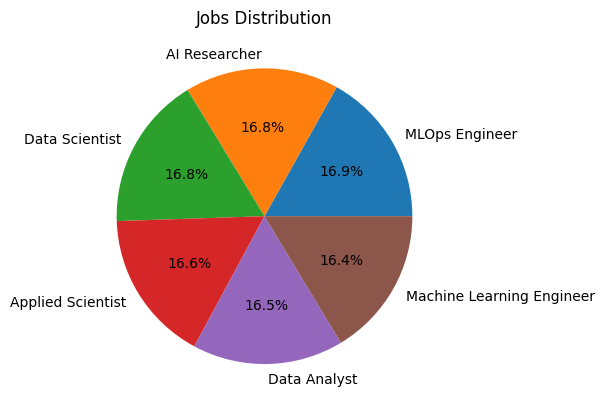

In [9]:
plt.pie(df["job_title"].value_counts(),labels=df["job_title"].value_counts().index,autopct="%1.1f%%");
plt.title("Jobs Distribution")
plt.show()

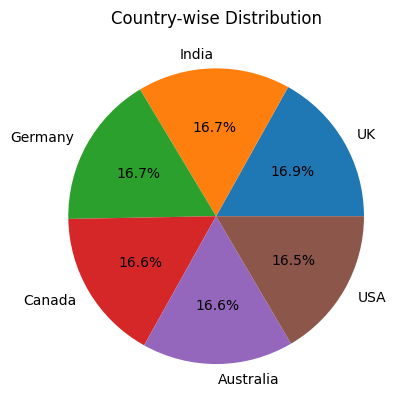

In [10]:
plt.pie(df["country"].value_counts(),labels=df["country"].value_counts().index,autopct="%1.1f%%");
plt.title("Country-wise Distribution")
plt.show()

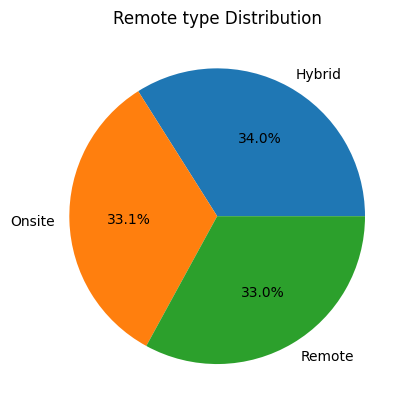

In [11]:
plt.pie(df["remote_type"].value_counts(),labels=df["remote_type"].value_counts().index,autopct="%1.1f%%");
plt.title("Remote type Distribution")
plt.show()

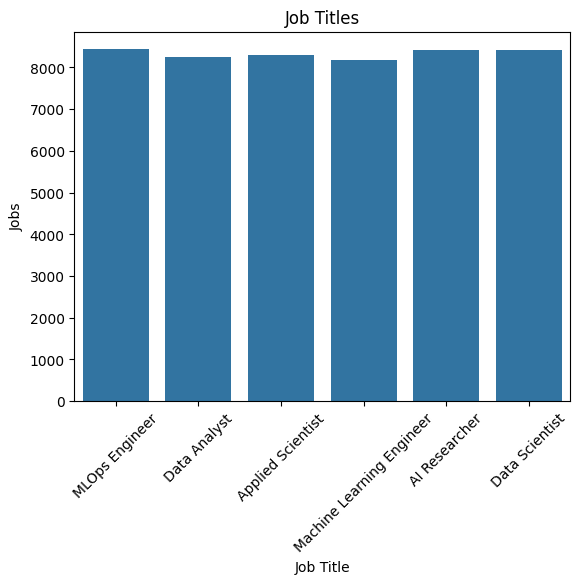

In [12]:
sns.countplot(x=df["job_title"]);
plt.title("Job Titles")
plt.ylabel("Jobs")
plt.xlabel("Job Title")
plt.xticks(rotation=45)
plt.show()

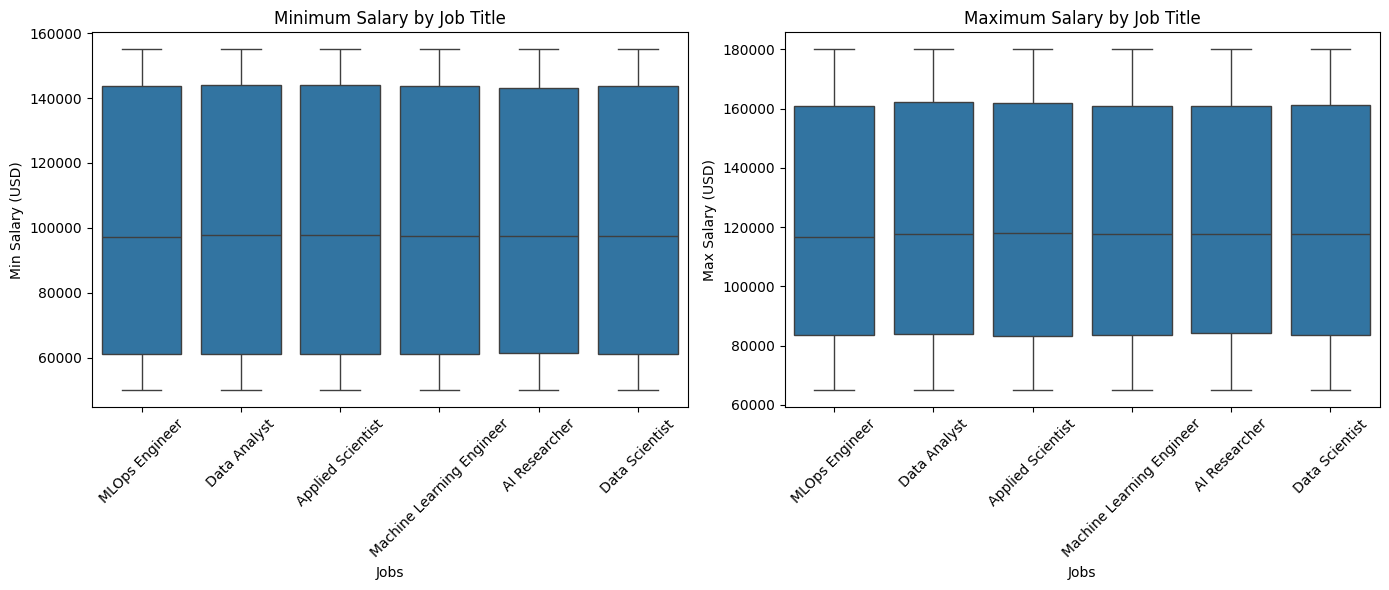

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x="job_title", y="salary_min_usd", ax=axes[0])
axes[0].set_title("Minimum Salary by Job Title")
axes[0].set_ylabel("Min Salary (USD)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel("Jobs")

sns.boxplot(data=df, x="job_title", y="salary_max_usd", ax=axes[1])
axes[1].set_title("Maximum Salary by Job Title")
axes[1].set_ylabel("Max Salary (USD)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel("Jobs")

plt.tight_layout()
plt.show()

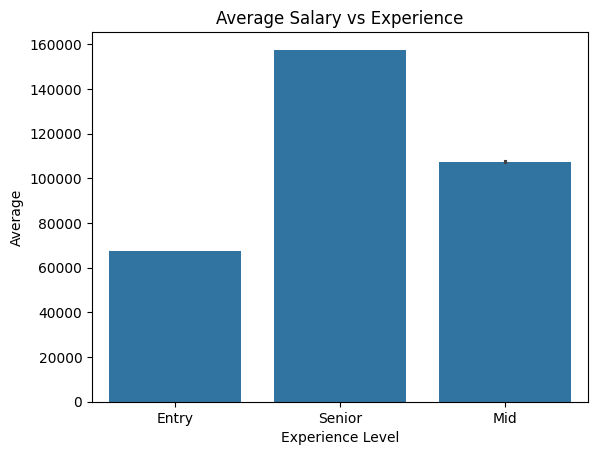

In [14]:
sns.barplot(data=df,x="experience_level",y="Average");
plt.xlabel("Experience Level");
plt.title("Average Salary vs Experience")
plt.show()

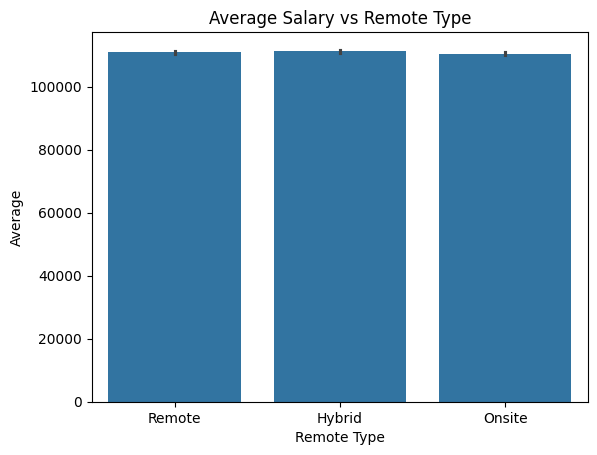

In [15]:
sns.barplot(data=df,x="remote_type",y="Average");
plt.xlabel("Remote Type");
plt.title("Average Salary vs Remote Type")
plt.show()

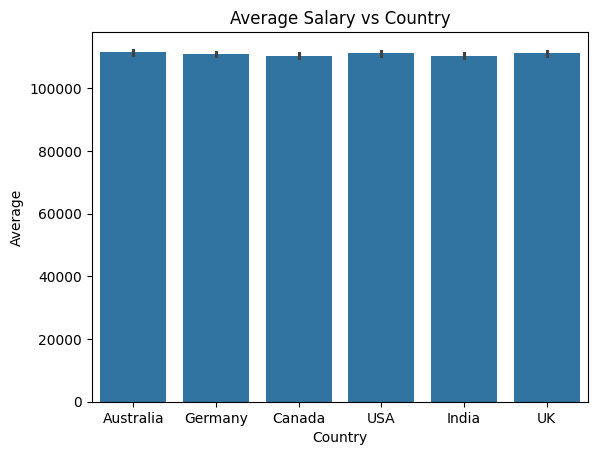

In [16]:
sns.barplot(data=df,x="country",y="Average");
plt.xlabel("Country");
plt.title("Average Salary vs Country")
plt.show()


Correlation Matrix:
                      min_experience_years  salary_min_usd  salary_max_usd  \
min_experience_years              1.000000        0.991867        0.980046   
salary_min_usd                    0.991867        1.000000        0.974541   
salary_max_usd                    0.980046        0.974541        1.000000   
posted_year                      -0.004057       -0.003718       -0.005150   
Average                           0.992254        0.993531        0.993698   

                      posted_year   Average  
min_experience_years    -0.004057  0.992254  
salary_min_usd          -0.003718  0.993531  
salary_max_usd          -0.005150  0.993698  
posted_year              1.000000 -0.004467  
Average                 -0.004467  1.000000  


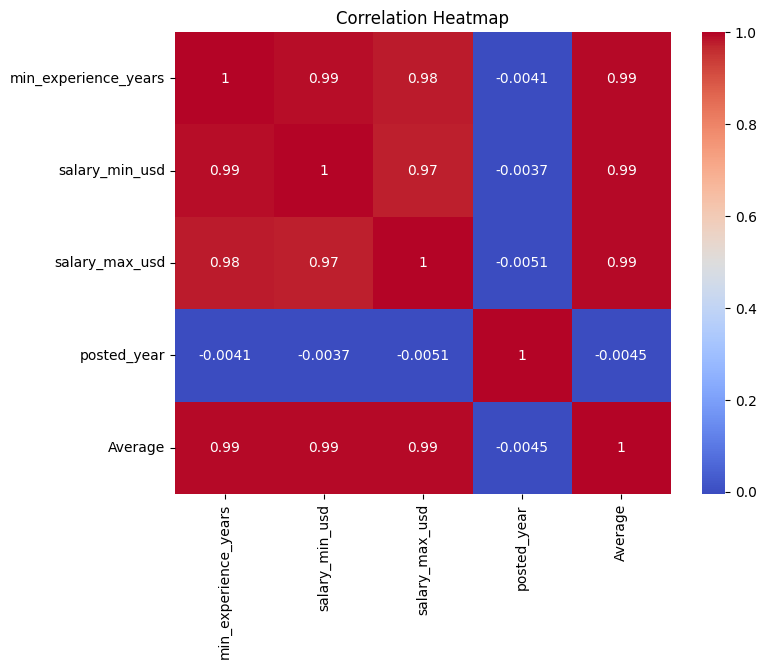

In [17]:
corr_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### [6] Hypothesis Formulation & [7] Hypothesis Testing

To validate the findings from the EDA, the following hypotheses were formulated to test the drivers of compensation in the AI market:

1. **Hypothesis 1:** Senior-level experience leads to a statistically significant increase in salary compared to entry-level roles.
2. **Hypothesis 2:** Remote roles offer higher compensation than onsite roles due to the global nature of AI talent competition.
3. **Hypothesis 3:** Company size significantly influences the salary floor for specialized AI roles.

---

#### **Significance Test: Experience Level vs. Salary**

To confirm if the pay gap seen in our visualizations is statistically significant for our stakeholders, an **Independent T-Test** was conducted comparing Senior and Entry-level salaries.



* **Null Hypothesis ($H_0$):** There is no significant difference in average salary between Senior and Entry-level AI professionals.
* **Alternative Hypothesis ($H_a$):** Senior-level professionals earn a significantly higher average salary.

## Key Insights: AI Jobs Analysis

- Average minimum experience needed in 2 years.
- The salary ranges between 50000 to 180000 usd.
- Maximum jobs were of MLOps Engineer.
- Maximum jobs were of tech industry.
- Maximum jobs were based in UK.
- Maximum jobs were of Hybrid type.
- Maximum person who got the jobs had mid-level experience.
- Maximum company who gave jobs were research labs.
- People with senior level experience had higher salary than mid and entry level.

### Conclusion & Next Steps

**Key Takeaways:**
* **Seniority is Key:** Experience level is the single most important factor for salary, far outweighing remote status or company type.
* **Remote Equality:** The AI market appears to have achieved "pay parity" between remote and onsite roles, as evidenced by the high p-value in our significance test.

**Next Steps:**
1. **Skill Analysis:** I recommend collecting data on specific programming languages (Python, C++, Mojo) to see which skillsets command the highest premiums.
2. **Advanced Modeling:** The next phase will involve a **Gradient Boosting Regressor** to predict AI salaries based on the highly significant features identified in this EDA.